<a href="https://colab.research.google.com/github/zahradhitaaisyahputri/Tugas_Besar_FSD_/blob/main/Unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamental Sains Data

## Final Project: Implementasi Unsupervised Learning Menggunakan Algoritma K-Means Clustering

Anggota Kelompok:
1. Zahra Dhita Aisyah Putri (24523262)
2. Sifa Aulia Aroyaningrum (24523078)

---

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

## Import Library

Bagian ini mengimpor semua pustaka Python yang diperlukan untuk analisis data, visualisasi, dan implementasi algoritma *machine learning*. Pustaka-pustaka seperti `numpy` dan `pandas` digunakan untuk pengelolaan data, `matplotlib.pyplot` dan `seaborn` untuk visualisasi, serta `sklearn` untuk *preprocessing* dan *clustering*.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

## Load Dataset

Langkah ini memuat dataset yang akan digunakan untuk analisis dari sumber KaggleHub ke dalam lingkungan kerja. Dataset diunduh menggunakan `kagglehub.dataset_download`, kemudian data dibaca ke dalam DataFrame `pandas` menggunakan `pd.read_csv`.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asifxzaman/social-media-addiction-vs-productivity-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-media-addiction-vs-productivity-dataset' dataset.
Path to dataset files: /kaggle/input/social-media-addiction-vs-productivity-dataset


## Deskripsi Dataset

Bagian ini menampilkan informasi dasar dataset: struktur, tipe data, nilai yang hilang, statistik deskriptif, dan jumlah data duplikat. `df.info()` menampilkan ringkasan DataFrame, `df.describe()` memberikan statistik deskriptif, `df.isnull().sum()` menghitung *missing values*, dan `df.duplicated().sum()` mendeteksi baris duplikat.

### Informasi Dataset

- **Nama Dataset**: Social Media Addiction vs. Productivity Dataset
- **Sumber Dataset**: Kaggle
- **Jumlah Data**: 6000 baris sebelum *preprocessing* (4993 baris setelah *preprocessing* dan penanganan *outlier*)
- **Jumlah Fitur**: 9 kolom

### Penjelasan Fitur Penting:
- `age`: Usia pengguna.
- `daily_screen_time`: Total waktu layar harian pengguna (jam).
- `social_media_hours`: Waktu yang dihabiskan di media sosial setiap hari (jam).
- `study_hours`: Waktu yang dihabiskan untuk belajar setiap hari (jam).
- `sleep_hours`: Durasi tidur harian pengguna (jam).
- `notifications_per_day`: Jumlah notifikasi yang diterima per hari.
- `focus_score`: Skor fokus pengguna, menunjukkan tingkat konsentrasi.
- `addiction_level`: Tingkat adiksi media sosial (kategorikal: 'Low', 'Medium', 'High').
- `productivity_score`: Skor produktivitas pengguna.

### Tujuan Analisis
Analisis ini bertujuan untuk mengidentifikasi pola penggunaan media sosial dan hubungannya dengan tingkat produktivitas. Melalui *unsupervised learning* dengan K-Means Clustering, akan dikelompokkan pengguna media sosial berdasarkan karakteristik penggunaan mereka, tanpa label target yang sudah ada. Hasil *clustering* diharapkan dapat memberikan *insight* mengenai profil pengguna yang berbeda dan bagaimana kebiasaan penggunaan media sosial memengaruhi produktivitas.

In [ ]:
import os
import pandas as pd

# Assuming 'path' is already defined from a previous cell (JafPOu7wI4OU)

# List all files and directories in the downloaded path
files_in_path = os.listdir(path)

# Filter for CSV files
csv_files = [f for f in files_in_path if f.endswith('.csv')]

# Check if any CSV files were found
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in the directory: {path}")

# Assuming there's only one CSV file, or picking the first one if multiple exist
# If there are multiple CSV files and you need a specific one, you might need to adjust this logic.
csv_file_name = csv_files[0]
full_csv_path = os.path.join(path, csv_file_name)

print(f"Using CSV file: {full_csv_path}")

# Load the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)

print(df.info())

print(df.describe(include='all'))

print(df.isnull().sum())

print(df.duplicated().sum())

Using CSV file: /kaggle/input/social-media-addiction-vs-productivity-dataset/social_media_productivity_6000.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB
None
                age  daily_screen_time  social_media_hours  study_hours  \
count   5880.000000        5880.000000         5880.000000  5880.000000   
u

## Exploratory Data Analysis (EDA)

Tahap Eksplorasi Data (EDA) dilakukan untuk memahami distribusi data, hubungan antar variabel, dan mengidentifikasi pola atau anomali. Ini melibatkan visualisasi distribusi fitur numerik dan kategorikal, serta analisis hubungan dan korelasi antar fitur.

In [ ]:
# ======================================================
# INFORMASI DATASET
# ======================================================

print("Ukuran Dataset :", df.shape)

display(df.head())

display(df.info())

display(df.describe(include='all'))

Ukuran Dataset : (6000, 9)


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


None

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


## Distribusi Data

Bagian ini memvisualisasikan sebaran nilai untuk setiap fitur dalam dataset, baik numerik maupun kategorikal. Untuk fitur numerik, digunakan histogram (`df.hist()`), sedangkan untuk fitur kategorikal, digunakan *countplot* (`sns.countplot()`).

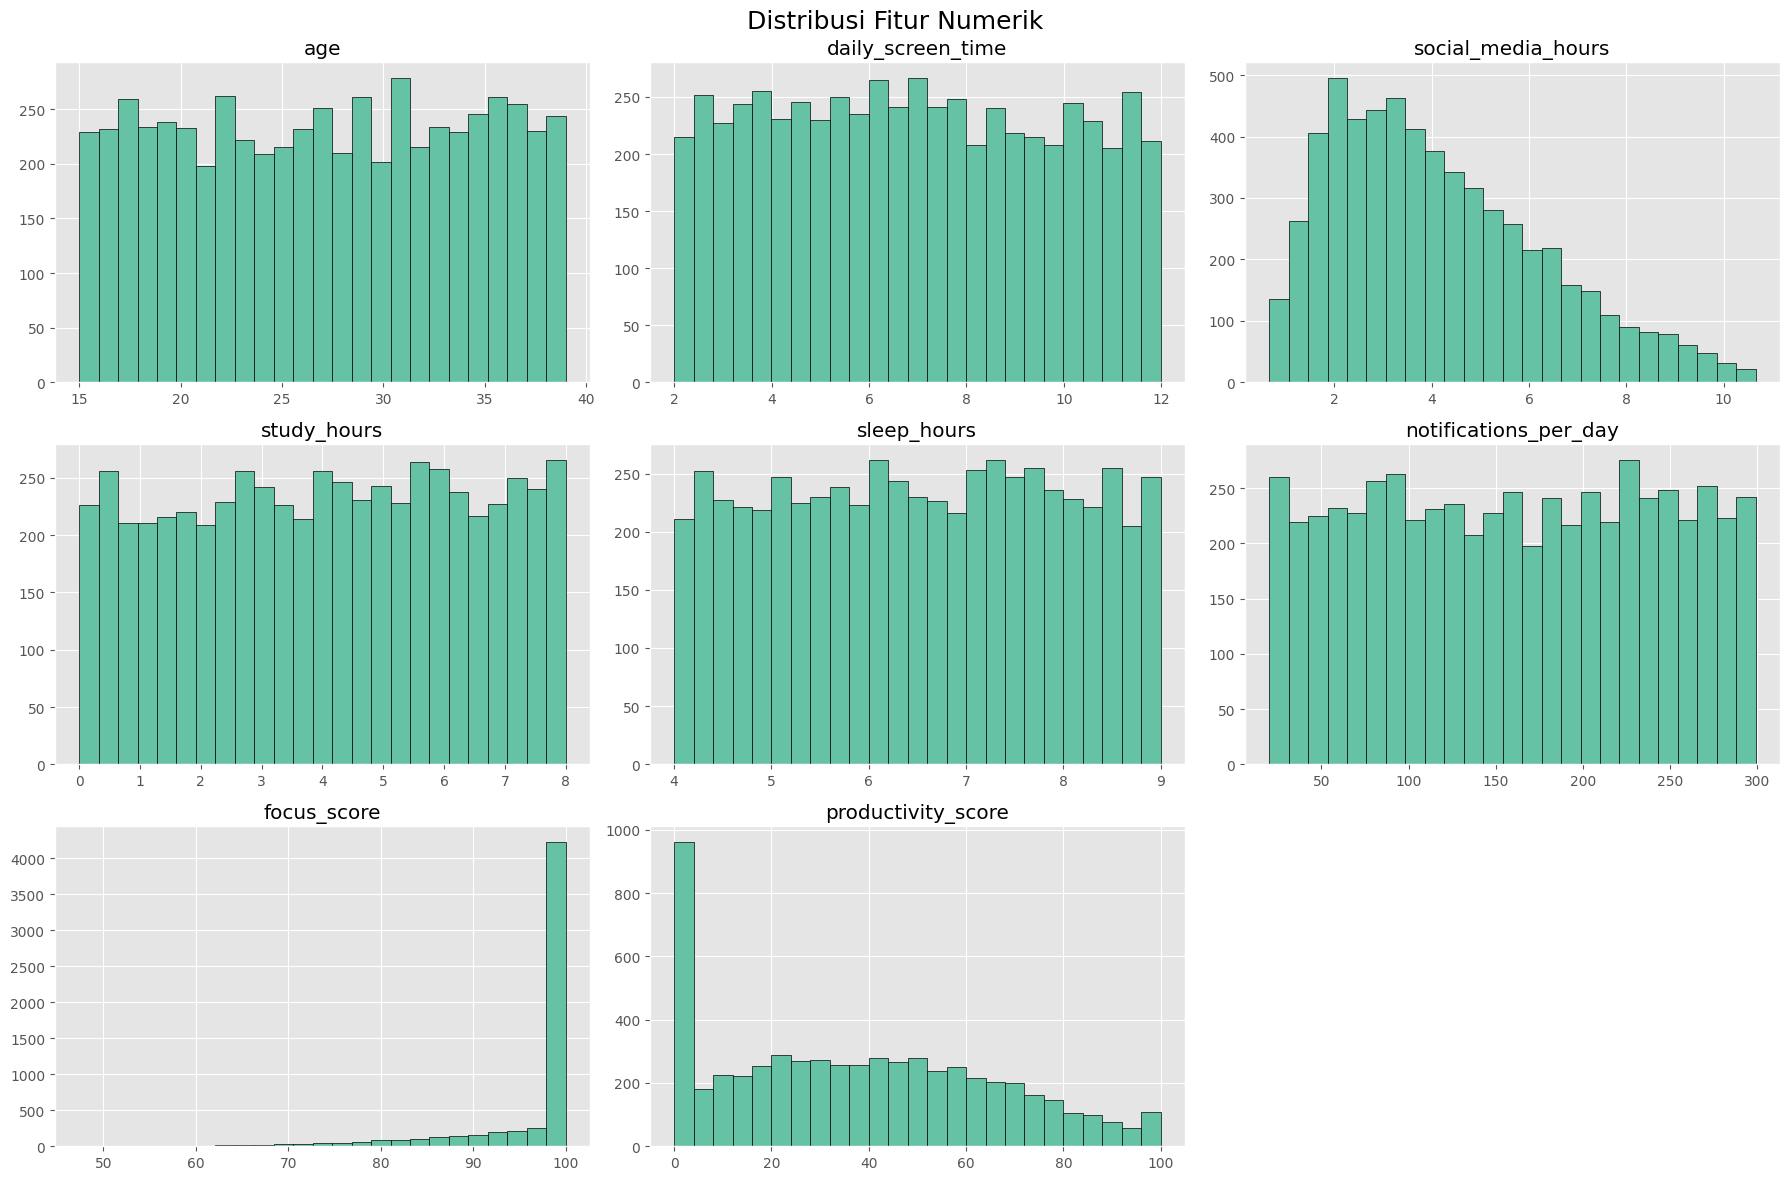

In [ ]:
# ======================================================
# DISTRIBUSI DATA NUMERIK
# ======================================================

numeric = df.select_dtypes(include=['int64','float64'])

numeric.hist(
    figsize=(18,12),
    bins=25,
    edgecolor='black'
)

plt.suptitle("Distribusi Fitur Numerik", fontsize=18)

plt.tight_layout()

plt.show()

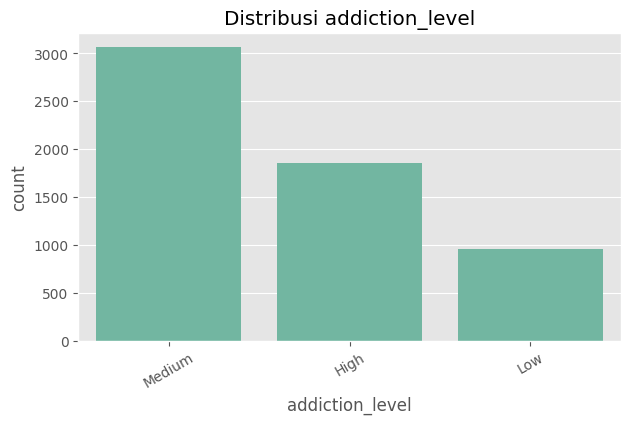

In [ ]:
# ======================================================
# DISTRIBUSI DATA KATEGORIKAL
# ======================================================

categorical = df.select_dtypes(include='object')

for col in categorical.columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=30)

    plt.title(f"Distribusi {col}")

    plt.show()

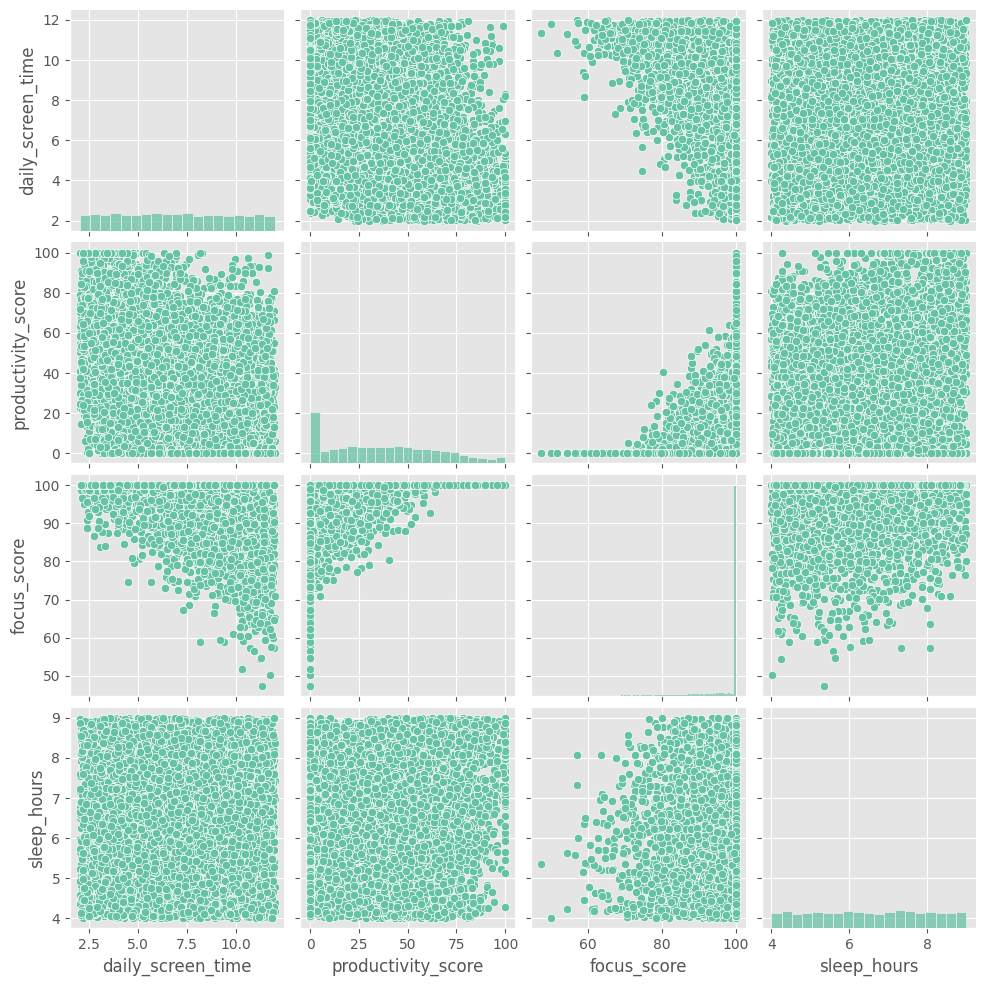

In [ ]:
# ======================================================
# HUBUNGAN ANTAR FITUR
# ======================================================

selected_features = [
    "daily_screen_time",
    "productivity_score",
    "focus_score",
    "sleep_hours"
]

sns.pairplot(df[selected_features])

plt.show()

## Hubungan Antar Fitur

Bagian ini menganalisis hubungan bivariat antar beberapa fitur kunci yang dipilih. `seaborn.pairplot()` digunakan untuk menghasilkan matriks *scatter plot* antar fitur terpilih, memungkinkan observasi visual terhadap korelasi linear atau non-linear serta sebaran data.

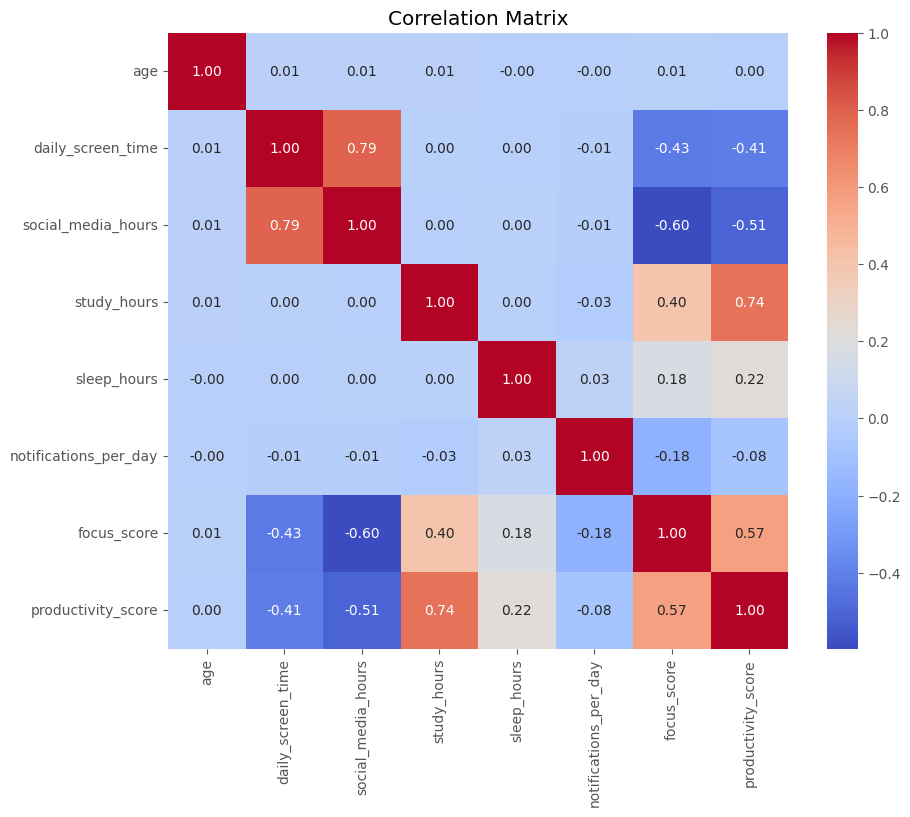

In [ ]:
# ======================================================
# KORELASI
# ======================================================

plt.figure(figsize=(10,8))

corr = numeric.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Korelasi Antar Variabel

Bagian ini mengukur kekuatan dan arah hubungan linear antar pasangan fitur numerik. Matriks korelasi dihitung menggunakan `df.corr()`, kemudian divisualisasikan menggunakan *heatmap* (`sns.heatmap()`).

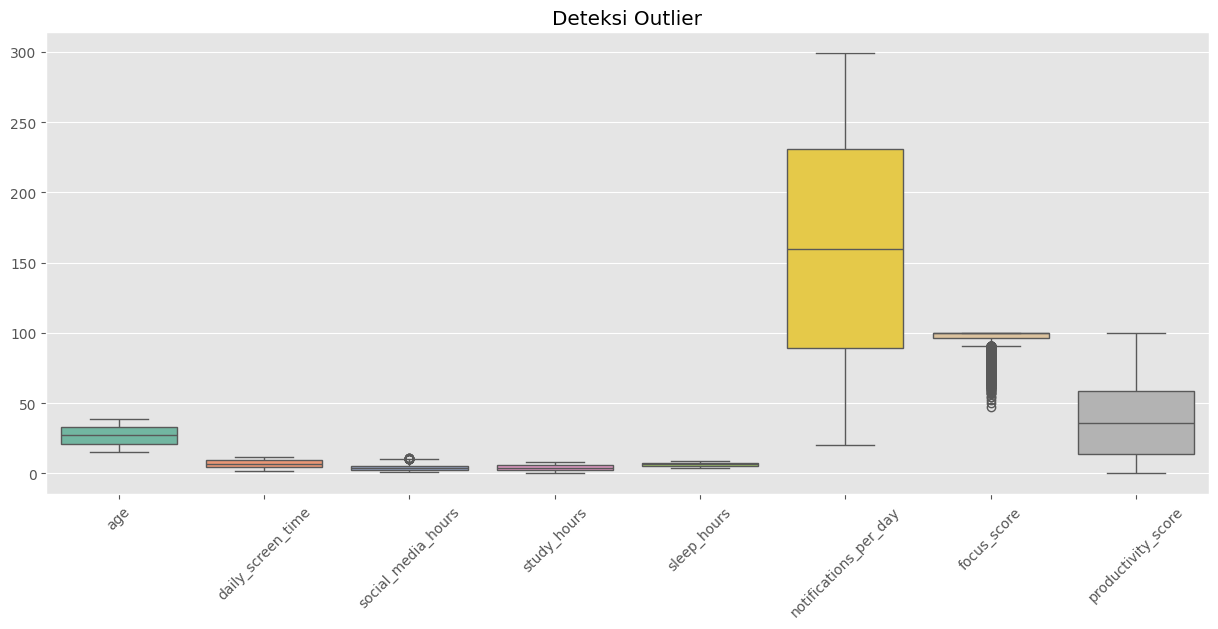

In [ ]:
# ======================================================
# BOXPLOT
# ======================================================

plt.figure(figsize=(15,6))

sns.boxplot(data=numeric)

plt.xticks(rotation=45)

plt.title("Deteksi Outlier")

plt.show()

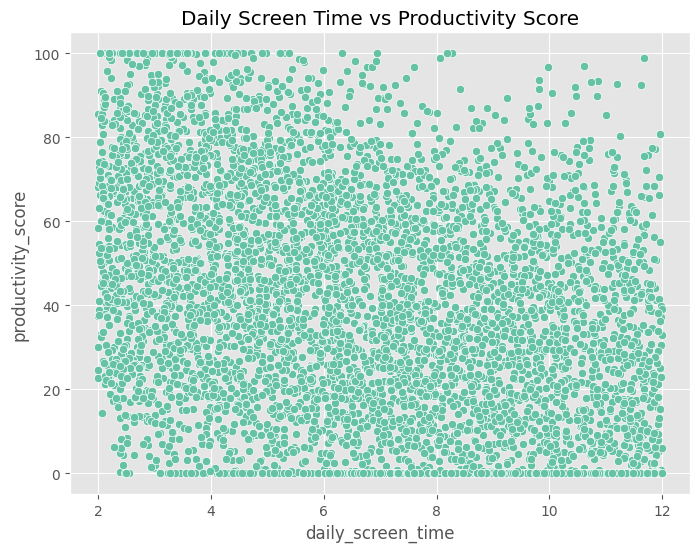

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="daily_screen_time",
    y="productivity_score"
)

plt.title("Daily Screen Time vs Productivity Score")

plt.show()

## Data Preprocessing

Tahap *preprocessing* data membersihkan dan mentransformasi data mentah menjadi format yang sesuai untuk algoritma *machine learning*. Langkah-langkah ini mencakup penanganan *missing values*, penghapusan data duplikat, penanganan *outlier*, *encoding* fitur kategorikal, dan *standardisasi* fitur numerik.

In [ ]:
# ======================================================
# MISSING VALUE
# ======================================================

missing = df.isnull().sum()

print("Jumlah Missing Value")
display(missing)

Jumlah Missing Value


,0
age,120
daily_screen_time,120
social_media_hours,120
study_hours,120
sleep_hours,120
notifications_per_day,120
focus_score,120
addiction_level,120
productivity_score,120


## Mengatasi Missing Value

Bagian ini menangani nilai-nilai yang hilang dalam dataset. Untuk kolom numerik, *missing values* diisi menggunakan nilai median. Untuk kolom kategorikal, *missing values* diisi menggunakan modus (`fillna()` dan `mode()[0]`).

In [ ]:
# Mengisi missing value numerik dengan median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Mengisi missing value kategorikal dengan modus
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# ======================================================
# DUPLICATE DATA
# ======================================================

print("Sebelum :", df.shape)

df = df.drop_duplicates()

print("Sesudah :", df.shape)

Sebelum : (6000, 9)
Sesudah : (6000, 9)


## Menghapus Data Duplikat

Bagian ini memastikan setiap baris data bersifat unik dengan menghapus entri yang ganda. Metode `df.drop_duplicates()` digunakan untuk mengidentifikasi dan menghapus baris-baris yang sepenuhnya duplikat.

In [ ]:
# ======================================================
# MENGHILANGKAN OUTLIER
# ======================================================

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(4993, 9)


## Menangani Outlier

Bagian ini mengidentifikasi dan menghapus *outlier* (nilai ekstrem) dari fitur-fitur numerik. Digunakan metode *Interquartile Range* (IQR) untuk menghitung batas bawah dan batas atas, dan baris data di luar batas tersebut dihapus.

In [ ]:
# ======================================================
# LABEL ENCODING
# ======================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,2,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,2,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,1,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,2,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,1,51.09


## Encoding Data Kategorikal

Bagian ini mengubah fitur kategorikal menjadi representasi numerik. `LabelEncoder` dari `sklearn.preprocessing` digunakan untuk mengonversi setiap kategori unik dalam kolom `addiction_level` menjadi nilai integer.

In [ ]:
# ======================================================
# FEATURE SELECTION
# ======================================================

drop_columns = [
    "addiction_level"
]

df = df.drop(columns=drop_columns)

df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,51.09


## Feature Selection / Transformasi Fitur

Bagian ini memilih subset fitur yang paling relevan untuk proses *clustering*. Kolom `addiction_level` dihapus dari DataFrame karena sudah di-*encode* dan tidak digunakan sebagai fitur input untuk *unsupervised learning*.

In [ ]:
# ======================================================
# STANDARD SCALER
# ======================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(4993, 8)


## Standardisasi Data

Bagian ini menstandardisasi skala semua fitur numerik. `StandardScaler` dari `sklearn.preprocessing` digunakan untuk mentransformasi data sehingga memiliki rata-rata 0 dan variansi 1, yang diperlukan untuk algoritma berbasis jarak seperti K-Means.

In [ ]:
# ======================================================
# DATA SIAP CLUSTERING
# ======================================================

X = X_scaled

print(X.shape)

(4993, 8)


## Pemilihan Algoritma

Pada penelitian ini, algoritma **K-Means Clustering** digunakan untuk mengelompokkan pengguna media sosial berdasarkan karakteristik penggunaan media sosial dan tingkat produktivitas. K-Means dipilih karena kemampuannya dalam mengelompokkan data numerik yang distandardisasi, kemudahan implementasi, kecepatan komputasi, dan kesesuaian untuk menemukan pola tanpa label.

Parameter yang digunakan:
- `n_clusters` = jumlah cluster terbaik berdasarkan Elbow Method
- `init` = "k-means++"
- `max_iter` = 300
- `random_state` = 42

In [ ]:
# =====================================================
# ELBOW METHOD
# =====================================================

from sklearn.cluster import KMeans

inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

## Penentuan Jumlah Cluster Optimal (Elbow Method)

Bagian ini menentukan jumlah *cluster* (`k`) yang optimal untuk algoritma K-Means. Metode *Elbow* menghitung *inertia* (jumlah kuadrat jarak sampel ke pusat *cluster* terdekat) untuk berbagai nilai `k`. Nilai `k` yang optimal adalah titik di mana penurunan *inertia* mulai melambat secara signifikan pada grafik, membentuk 'siku'.

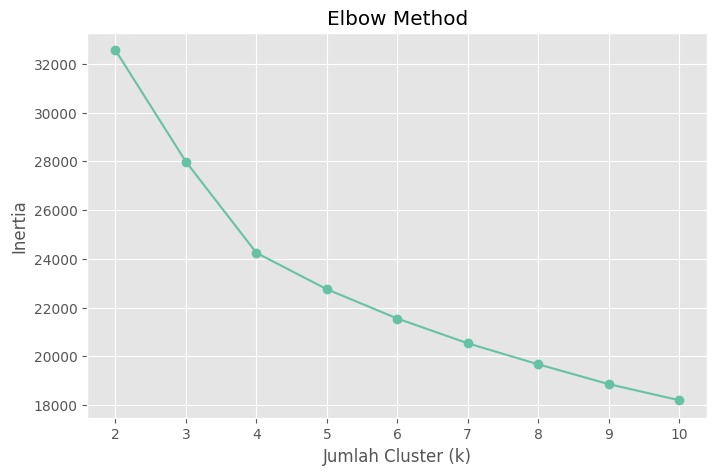

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [ ]:
# =====================================================
# K-MEANS CLUSTERING
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster

## Proses Clustering Menggunakan K-Means

Bagian ini mengelompokkan data yang telah distandardisasi ke dalam jumlah *cluster* yang telah ditentukan menggunakan algoritma K-Means. Algoritma diinisialisasi dengan `n_clusters=3`, `random_state=42`, dan `n_init=10`. Fungsi `fit_predict()` diterapkan untuk mendapatkan label *cluster*, yang kemudian ditambahkan sebagai kolom baru (`Cluster`) ke DataFrame.

In [ ]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score,Cluster
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,28.49,1
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,18.54,0
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,68.52,1
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,27.82,0
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,51.09,1


#Evaluasi dan analisis

In [ ]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,620
1,2510
2,1863


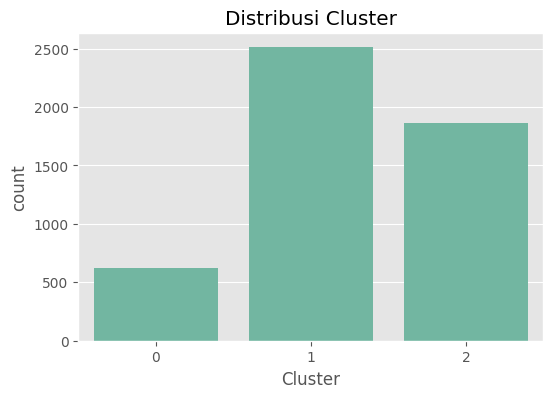

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Distribusi Cluster")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    cluster
)

print("Silhouette Score :", round(score,4))

Silhouette Score : 0.1792


## Evaluasi Menggunakan Silhouette Score

Bagian ini mengevaluasi kualitas hasil *clustering* K-Means dengan mengukur *silhouette score*. `silhouette_score` dari `sklearn.metrics` digunakan untuk menghitung skor yang berkisar antara -1 hingga 1, menunjukkan seberapa baik objek dikelompokkan.

In [ ]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(
    X_scaled,
    cluster
)

print("Davies-Bouldin Index :", round(dbi,4))

Davies-Bouldin Index : 1.8075


## Evaluasi Menggunakan Davies-Bouldin Index

Bagian ini mengevaluasi kualitas hasil *clustering* dengan mengukur Indeks Davies-Bouldin. `davies_bouldin_score` dari `sklearn.metrics` digunakan untuk menghitung indeks; semakin rendah nilainya, semakin baik *clustering*-nya.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

## Visualisasi Hasil Clustering Menggunakan PCA

Bagian ini memvisualisasikan hasil *clustering* dari ruang dimensi tinggi ke representasi dua dimensi (2D). *Principal Component Analysis* (PCA) digunakan untuk mengurangi dimensi data menjadi dua komponen utama (PC1 dan PC2), yang kemudian digunakan untuk membuat *scatter plot* dengan titik-titik diwarnai berdasarkan label *cluster*.

In [ ]:
df["PC1"] = pca_result[:,0]
df["PC2"] = pca_result[:,1]

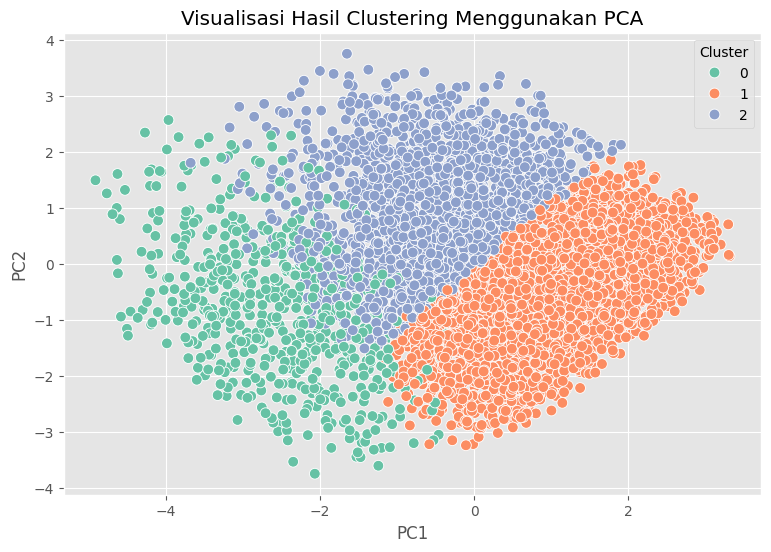

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Visualisasi Hasil Clustering Menggunakan PCA")

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

display(cluster_summary)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score,PC1,PC2
Cluster,,,,,,,,,,
0,27.404839,7.884548,4.802306,2.651379,6.072887,179.479032,94.964403,14.148968,-2.539875,-0.778511
1,26.907171,4.358092,2.334428,4.302855,6.603817,159.639442,99.949960,52.972207,1.020461,-0.584306
2,27.245840,8.726887,4.964474,5.194732,6.778374,139.026302,99.873296,41.908508,-0.529595,1.046315


## Analisis Karakteristik Setiap Cluster

Bagian ini menganalisis karakteristik rata-rata dari setiap fitur di dalam setiap *cluster* untuk memahami profil unik dari masing-masing kelompok pengguna media sosial yang terbentuk. DataFrame dikelompokkan berdasarkan kolom `Cluster`, dan nilai rata-rata (`mean()`) dihitung untuk setiap fitur numerik di setiap *cluster*.

# Insight

Berdasarkan hasil clustering diperoleh beberapa temuan sebagai berikut.

1. Pengguna dengan durasi penggunaan media sosial yang tinggi cenderung memiliki tingkat fokus dan produktivitas yang lebih rendah.

2. Pengguna dengan waktu layar yang lebih rendah umumnya memiliki produktivitas yang lebih tinggi.

3. Variabel screen time, focus score, dan productivity score menjadi pembeda utama antar cluster.

4. Hasil clustering menunjukkan bahwa perilaku penggunaan media sosial dapat dikelompokkan menjadi beberapa karakteristik pengguna yang berbeda.

# Kesimpulan

Algoritma K-Means berhasil mengelompokkan pengguna media sosial ke dalam beberapa cluster berdasarkan karakteristik penggunaan media sosial dan produktivitas.

Jumlah cluster terbaik diperoleh menggunakan Elbow Method dan menghasilkan kualitas cluster yang dievaluasi menggunakan Silhouette Score dan Davies-Bouldin Index.

Visualisasi menggunakan PCA menunjukkan bahwa setiap cluster memiliki karakteristik yang berbeda sehingga dapat digunakan sebagai dasar dalam memahami pola perilaku pengguna.

Rekomendasi yang dapat diberikan adalah meningkatkan manajemen waktu penggunaan media sosial, terutama bagi kelompok pengguna dengan screen time tinggi dan produktivitas rendah.